In [6]:
import pandas as pd

print("Starting Phase 1 & 2: Data Validation and Master Dataset Generation...\n")
    
# ==========================================
# 1. LOAD AND CLEAN PRICE DATA
# ==========================================

print("Loading Flower price 2010-16.xls...")
xls = pd.ExcelFile("Flower price 2010-16.xls")
all_years = [pd.read_excel(xls, sheet) for sheet in xls.sheet_names]
prices_df = pd.concat(all_years, ignore_index=True)
prices_df['DATE'] = pd.to_datetime(prices_df['DATE'])

print(f"Price Data: {len(prices_df)} rows. Range: {prices_df['DATE'].min().date()} to {prices_df['DATE'].max().date()}")
print(f"Price Extremes - Min: ₹{prices_df['PRICES'].min()}, Max: ₹{prices_df['PRICES'].max()}\n")

Starting Phase 1 & 2: Data Validation and Master Dataset Generation...

Loading Flower price 2010-16.xls...
Price Data: 2557 rows. Range: 2010-01-01 to 2016-12-31
Price Extremes - Min: ₹10, Max: ₹2909



In [11]:
# ==========================================
# 2. LOAD AND CLEAN NASA WEATHER DATA
# ==========================================
print("Loading weather.csv (NASA POWER data)...")
weather_df = pd.read_csv("weather.csv")

# The NASA file has empty rows at the bottom. We must drop them first.
weather_df = weather_df.dropna(subset=['YEAR', 'MO', 'DY'])

# Convert YEAR, MO, DY into a standard Pandas DATE column
weather_df['DATE'] = pd.to_datetime(
    weather_df[['YEAR', 'MO', 'DY']].rename(columns={'MO': 'MONTH', 'DY': 'DAY'})
)

print(f"Weather Data: {len(weather_df)} rows after dropping NaNs.")
print(f"Rainfall Extremes - Max: {weather_df['PRECTOTCORR'].max()} mm (Severe Monsoon Event)")
print(f"With no Rainfall - Min: {weather_df['PRECTOTCORR'].min()} mm (Severe Monsoon Event)\n")


Loading weather.csv (NASA POWER data)...
Weather Data: 2557 rows after dropping NaNs.
Rainfall Extremes - Max: 154.45 mm (Severe Monsoon Event)
With no Rainfall - Min: 0.0 mm (Severe Monsoon Event)



In [21]:
# ==========================================
# 3. MERGE INTO MASTER DATASET
# ==========================================
print("Merging Price and Weather data on DATE...")
master_df = pd.merge(prices_df, weather_df, on="DATE", how="inner")

# Keep only the columns we actually need for the project
columns_to_keep = ['DATE', 'PRICES', 'T2M', 'T2M_RANGE', 'RH2M', 'PRECTOTCORR']
master_df = master_df[columns_to_keep]

# Rename columns to be human-readable as requested by the guide's Data Dictionary
master_df = master_df.rename(columns={
    'PRICES': 'PRICE_INR',           # <--- This line was missing in your code
    'T2M': 'MEAN_TEMP_C',
    'T2M_RANGE': 'TEMP_RANGE_C',
    'RH2M': 'HUMIDITY_PERCENT',
    'PRECTOTCORR': 'RAINFALL_MM'
})

# Calculate Max and Min Temp
master_df['MAX_TEMP_C'] = round(master_df['MEAN_TEMP_C'] + (master_df['TEMP_RANGE_C'] / 2), 2)
master_df['MIN_TEMP_C'] = round(master_df['MEAN_TEMP_C'] - (master_df['TEMP_RANGE_C'] / 2), 2)

# Reorder columns to strictly match the guide's table format
final_columns = ['DATE', 'PRICE_INR', 'RAINFALL_MM', 'MAX_TEMP_C', 'MIN_TEMP_C', 'MEAN_TEMP_C', 'HUMIDITY_PERCENT']
master_df = master_df[final_columns]

print("--- FINAL MASTER DATASET QUALITY AUDIT ---")
print(f"Total Rows: {len(master_df)} (One row per day)")
print(f"Missing Values: {master_df.isnull().sum().sum()}")
print(f"Duplicate Dates: {master_df['DATE'].duplicated().sum()}")

# Save the final file
output_file = "master_dataset_v1.csv"
master_df.to_csv(output_file, index=False)
print(f"\nSuccess! Saved clean dataset to {output_file}")

# Display the first 5 rows in Jupyter
master_df.head()

Merging Price and Weather data on DATE...
--- FINAL MASTER DATASET QUALITY AUDIT ---
Total Rows: 2557 (One row per day)
Missing Values: 0
Duplicate Dates: 0

Success! Saved clean dataset to master_dataset_v1.csv


,DATE,PRICE_INR,RAINFALL_MM,MAX_TEMP_C,MIN_TEMP_C,MEAN_TEMP_C,HUMIDITY_PERCENT
0,2010-01-01,404,0.0,26.88,22.08,24.48,81.12
1,2010-01-02,404,0.0,29.25,19.39,24.32,74.47
2,2010-01-03,404,0.0,28.28,18.36,23.32,72.39
3,2010-01-04,404,0.0,28.51,17.85,23.18,68.85
4,2010-01-05,404,0.0,29.06,17.98,23.52,68.83


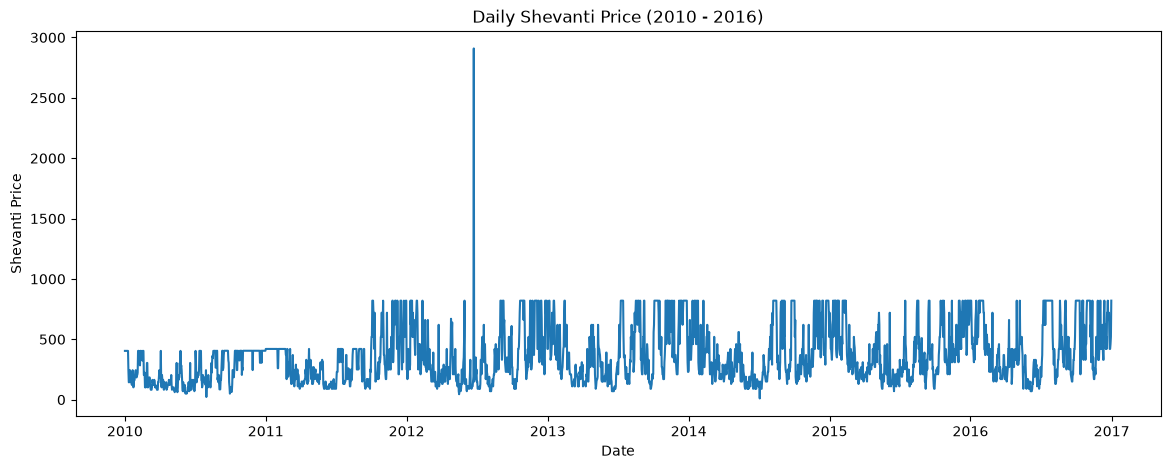

In [17]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(14,5))
plt.plot(prices_df["DATE"], prices_df["PRICES"])


plt.xlabel("Date")
plt.ylabel("Shevanti Price")
plt.title("Daily Shevanti Price (2010 - 2016)")

plt.show()


In [ ]:
# ==========================================
# PHASE 3
# ==========================================

import pandas as pd

print("Starting Phase 3: Feature Engineering...")

# Load the master dataset from Phase 2
df = pd.read_csv("master_dataset_v1.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

print(f"Loaded {len(df)} rows. Dataset ready for feature engineering.")

Starting Phase 3: Feature Engineering...
Loaded 2557 rows. Dataset ready for feature engineering.


In [23]:
# ==========================================
# 1. RECENT PRICE HISTORY
# ==========================================
# Past individual days
df['PRICE_LAG_1'] = df['PRICE_INR'].shift(1)
df['PRICE_LAG_2'] = df['PRICE_INR'].shift(2)
df['PRICE_LAG_3'] = df['PRICE_INR'].shift(3)
df['PRICE_LAG_7'] = df['PRICE_INR'].shift(7)

# Moving summaries (shifted by 1 to prevent data leakage)
df['PRICE_3D_MEAN'] = round(df['PRICE_INR'].rolling(window=3).mean().shift(1), 2)
df['PRICE_7D_MEAN'] = round(df['PRICE_INR'].rolling(window=7).mean().shift(1), 2)

print("Price history features created.")

Price history features created.


In [24]:
# ==========================================
# 2. LAGGED WEATHER
# ==========================================
# Past individual weather metrics
df['RAIN_LAG_1'] = df['RAINFALL_MM'].shift(1)
df['MAX_TEMP_LAG_1'] = df['MAX_TEMP_C'].shift(1)
df['HUMIDITY_LAG_1'] = df['HUMIDITY_PERCENT'].shift(1)

print("Lagged weather features created.")

Lagged weather features created.


In [25]:
# ==========================================
# 3. ACCUMULATED RAINFALL
# ==========================================
# Rolling sums representing sustained weather conditions
df['RAIN_3D_SUM'] = df['RAINFALL_MM'].rolling(window=3).sum().shift(1)
df['RAIN_7D_SUM'] = df['RAINFALL_MM'].rolling(window=7).sum().shift(1)

print("Accumulated rainfall features created.")

Accumulated rainfall features created.


In [26]:
# ==========================================
# 4. CONSECUTIVE CONDITIONS
# ==========================================
# Define a "Rainy Day" as > 1mm of rain
is_rainy = df['RAINFALL_MM'] > 1.0 

# Calculate the streak of rainy days
# The cumsum logic creates a unique ID for each block of True/False values
df['CONSEC_RAIN_DAYS'] = is_rainy.groupby((is_rainy != is_rainy.shift()).cumsum()).cumcount() + 1
df['CONSEC_RAIN_DAYS'] = df['CONSEC_RAIN_DAYS'] * is_rainy # Keep count only if it is actually raining

# Shift by 1 so the model predicts today based on yesterday's streak
df['CONSEC_RAIN_DAYS_LAG1'] = df['CONSEC_RAIN_DAYS'].shift(1)

# Drop the un-shifted column immediately to prevent data leakage
df = df.drop(columns=['CONSEC_RAIN_DAYS']) 

print("Consecutive conditions tracked.")

Consecutive conditions tracked.


In [28]:
# ==========================================
# 5. WEATHER STRESS FLAGS (Event-Style)
# ==========================================
# Find statistical thresholds from the historical data
heavy_rain_threshold = df[df['RAINFALL_MM'] > 0]['RAINFALL_MM'].quantile(0.90) # Top 10% of rainy days
hot_temp_threshold = df['MAX_TEMP_C'].quantile(0.95)                           # Top 5% hottest days
humid_threshold = df['HUMIDITY_PERCENT'].quantile(0.95)                        # Top 5% most humid days

# Create binary flags (1 = Yes, 0 = No) and shift them to yesterday
df['FLAG_HEAVY_RAIN'] = (df['RAINFALL_MM'] >= heavy_rain_threshold).astype(int).shift(1)
df['FLAG_HOT_DAY'] = (df['MAX_TEMP_C'] >= hot_temp_threshold).astype(int).shift(1)
df['FLAG_HUMID_DAY'] = (df['HUMIDITY_PERCENT'] >= humid_threshold).astype(int).shift(1)

print("Weather stress flags computed.")

Weather stress flags computed.


In [29]:
# ==========================================
# 6. CLEAN UP & SAVE
# ==========================================
# Because we looked 7 days into the past (PRICE_LAG_7), the first 7 rows of our 
# dataset now have NaN (blank) values. We must drop them so the ML models don't crash.
df_features = df.dropna().reset_index(drop=True)

print(f"Original Rows: {len(df)}")
print(f"Rows after dropping 7-day NaNs: {len(df_features)}")
print(f"Thresholds used -> Heavy Rain: {heavy_rain_threshold:.1f}mm, Hot: {hot_temp_threshold:.1f}°C, Humid: {humid_threshold:.1f}%")

# Save to a new Phase 3 dataset
output_file = "feature_dataset_v1.csv"
df_features.to_csv(output_file, index=False)
print(f"\nSuccess! Phase 3 complete. Saved to {output_file}")

# Display the first 5 rows to verify visually
df_features.head()

Original Rows: 2557
Rows after dropping 7-day NaNs: 2550
Thresholds used -> Heavy Rain: 43.3mm, Hot: 33.8°C, Humid: 92.4%

Success! Phase 3 complete. Saved to feature_dataset_v1.csv


,DATE,PRICE_INR,RAINFALL_MM,MAX_TEMP_C,MIN_TEMP_C,MEAN_TEMP_C,HUMIDITY_PERCENT,PRICE_LAG_1,PRICE_LAG_2,PRICE_LAG_3,...,PRICE_7D_MEAN,RAIN_LAG_1,MAX_TEMP_LAG_1,HUMIDITY_LAG_1,RAIN_3D_SUM,RAIN_7D_SUM,CONSEC_RAIN_DAYS_LAG1,FLAG_HEAVY_RAIN,FLAG_HOT_DAY,FLAG_HUMID_DAY
0,2010-01-08,404,0.00,28.53,19.08,23.81,71.71,404.0,404.0,404.0,...,404.00,0.00,28.08,71.00,0.00,0.00,0.0,0.0,0.0,0.0
1,2010-01-09,404,0.00,29.19,20.77,24.98,75.18,404.0,404.0,404.0,...,404.00,0.00,28.53,71.71,0.00,0.00,0.0,0.0,0.0,0.0
2,2010-01-10,244,0.00,28.66,21.94,25.30,80.88,404.0,404.0,404.0,...,404.00,0.00,29.19,75.18,0.00,0.00,0.0,0.0,0.0,0.0
3,2010-01-11,144,0.27,27.76,21.92,24.84,82.83,244.0,404.0,404.0,...,381.14,0.00,28.66,80.88,0.00,0.00,0.0,0.0,0.0,0.0
4,2010-01-12,144,0.54,27.42,21.52,24.47,82.78,144.0,244.0,404.0,...,344.00,0.27,27.76,82.83,0.27,0.27,0.0,0.0,0.0,0.0


In [ ]:
# ==========================================
# PHASE 4 START
# ==========================================

# ==============================================================================
# CELL 1: CALCULATE STATISTICAL THRESHOLDS FOR WEATHER EVENTS
# What is happening: We are defining what "Extreme Weather" actually means 
# by looking at the mathematical distribution (the top 10% of days) 
# instead of just guessing arbitrary numbers.
# ==============================================================================

import pandas as pd
print("Phase 4: Defining Weather Events based on Distribution...\n")

# Load the dataset from Phase 3
df = pd.read_csv("feature_dataset_v1.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

# 1. RAINFALL THRESHOLDS
# Filter for days where it actually rained to find the true distribution of storms
rainy_days = df[df['RAINFALL_MM'] > 1.0]['RAINFALL_MM']
heavy_rain_thresh = rainy_days.quantile(0.90) # Top 10% of rainy days
prolonged_rain_thresh = 3 # 3 or more consecutive days of rain

# 2. TEMPERATURE & HUMIDITY THRESHOLDS
hot_thresh = df['MAX_TEMP_C'].quantile(0.90) # Top 10% hottest days
humid_thresh = df['HUMIDITY_PERCENT'].quantile(0.90) # Top 10% most humid days

print("--- Scientifically Defined Thresholds ---")
print(f"Heavy Rain: > {heavy_rain_thresh:.2f} mm/day (90th percentile of rainy days)")
print(f"Prolonged Rain: >= {prolonged_rain_thresh} consecutive days")
print(f"Extreme Heat: > {hot_thresh:.2f} °C (90th percentile of all days)")
print(f"Extreme Humidity: > {humid_thresh:.2f} % (90th percentile of all days)")

Phase 4: Defining Weather Events based on Distribution...

--- Scientifically Defined Thresholds ---
Heavy Rain: > 49.30 mm/day (90th percentile of rainy days)
Prolonged Rain: >= 3 consecutive days
Extreme Heat: > 32.95 °C (90th percentile of all days)
Extreme Humidity: > 91.49 % (90th percentile of all days)


In [33]:
# ==============================================================================
# CELL 2: EXTRACT RAINFALL EVENTS
# What is happening: We scan the 7-year dataset to find the exact dates where 
# Heavy Rain and Prolonged Rain occurred, and save them to an Event List.
# ==============================================================================

events_list = []

# 1. Extract HEAVY RAIN events
heavy_rain_dates = df[df['RAINFALL_MM'] > heavy_rain_thresh].copy()
for _, row in heavy_rain_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'HEAVY_RAIN', 'VALUE': row['RAINFALL_MM']})

# 2. Extract PROLONGED RAIN events (e.g., the 3rd, 4th, 5th day of continuous rain)
# We recreate the consecutive streak logic to find streaks >= 3 days
is_rainy = df['RAINFALL_MM'] > 1.0
streak = is_rainy.groupby((is_rainy != is_rainy.shift()).cumsum()).cumcount() + 1
df['TEMP_STREAK'] = streak * is_rainy

prolonged_rain_dates = df[df['TEMP_STREAK'] >= prolonged_rain_thresh].copy()
for _, row in prolonged_rain_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'PROLONGED_RAIN', 'VALUE': row['TEMP_STREAK']})

df = df.drop(columns=['TEMP_STREAK']) # Clean up the temporary column

print(f"Extracted {len(heavy_rain_dates)} Heavy Rain events and {len(prolonged_rain_dates)} Prolonged Rain events.")

Extracted 119 Heavy Rain events and 972 Prolonged Rain events.


In [34]:
# ==============================================================================
# CELL 3: EXTRACT TEMPERATURE & HUMIDITY EVENTS
# What is happening: We repeat the exact same extraction process for Extreme 
# Heat and Extreme Humidity, compiling everything into one Master Event DataFrame.
# ==============================================================================

# 3. Extract EXTREME HEAT events
hot_dates = df[df['MAX_TEMP_C'] > hot_thresh].copy()
for _, row in hot_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'EXTREME_HEAT', 'VALUE': row['MAX_TEMP_C']})

# 4. Extract EXTREME HUMIDITY events
humid_dates = df[df['HUMIDITY_PERCENT'] > humid_thresh].copy()
for _, row in humid_dates.iterrows():
    events_list.append({'DATE': row['DATE'], 'EVENT_TYPE': 'EXTREME_HUMIDITY', 'VALUE': row['HUMIDITY_PERCENT']})

# Compile into a single DataFrame and sort chronologically
events_df = pd.DataFrame(events_list)
events_df = events_df.sort_values('DATE').reset_index(drop=True)

print(f"Extracted {len(hot_dates)} Extreme Heat events and {len(humid_dates)} Extreme Humidity events.")

Extracted 252 Extreme Heat events and 255 Extreme Humidity events.


In [35]:
# ==============================================================================
# CELL 4: VALIDATE SAMPLE SIZES AND SAVE EVENT DATABASE
# We ensuring that we have enough historical examples for each event.
# We audit the counts and save the final file.
# ==============================================================================

# Check how many events we captured per category
event_counts = events_df['EVENT_TYPE'].value_counts()

print("--- Event Count Validation ---")
print(event_counts)
print("\nValidation Check: Do we have enough historical examples to run AI models later?")

# Loop through and flag any event type that has fewer than 30 examples
for event, count in event_counts.items():
    if count >= 30:
        print(f"[{event}]: OK ({count} examples - Statistically valid)")
    else:
        print(f"[{event}]: WARNING - Low sample size ({count} examples).")

# Save the Weather Signature Event Database for Phase 5
output_file = "weather_events_database.csv"
events_df.to_csv(output_file, index=False)
print(f"\nSuccess! Saved '{output_file}'. Ready for Phase 5 Window Engine.")

--- Event Count Validation ---
EVENT_TYPE
PROLONGED_RAIN      972
EXTREME_HUMIDITY    255
EXTREME_HEAT        252
HEAVY_RAIN          119
Name: count, dtype: int64

Validation Check: Do we have enough historical examples to run AI models later?
[PROLONGED_RAIN]: OK (972 examples - Statistically valid)
[EXTREME_HUMIDITY]: OK (255 examples - Statistically valid)
[EXTREME_HEAT]: OK (252 examples - Statistically valid)
[HEAVY_RAIN]: OK (119 examples - Statistically valid)

Success! Saved 'weather_events_database.csv'. Ready for Phase 5 Window Engine.
